In [43]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import os
import logging



sns.set(style="whitegrid")

In [44]:
LOG_DIR = "Data/logs"
os.makedirs(LOG_DIR, exist_ok=True)

log_file = f"{LOG_DIR}/eda_pipeline_{datetime.now().strftime('%Y%m%d_%H%M%S')}.txt"

logging.basicConfig(
    filename=log_file,
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s"
)

logging.info("EDA Pipeline Started")

In [45]:
import json
import logging
from pathlib import Path

# STEP 1: Define project root (IMPORTANT)
BASE_DIR = Path(r"e:\Automated-E-Commerce-Funnel-Analysis-Business-Intelligence-Pipeline")

# STEP 2: Build absolute path safely
METADATA_PATH = BASE_DIR / "Data" / "metadata" / "latest_metadata.json"

# STEP 3: Validate before reading (prevents crash)
if not METADATA_PATH.exists():
    raise FileNotFoundError(f"Metadata file not found at: {METADATA_PATH}")

# STEP 4: Read file safely
with open(METADATA_PATH, "r") as f:
    metadata = json.load(f)

logging.info(f"Loaded batch_id: {metadata.get('batch_id')}")

In [46]:
import os
print(os.getcwd())

e:\Automated-E-Commerce-Funnel-Analysis-Business-Intelligence-Pipeline\EDA


In [47]:
import os

print(os.path.exists("Data"))
print(os.path.exists("Data/raw"))
print(os.path.exists("Data/raw/orders"))

True
False
False


In [48]:
import os

print(os.path.exists("Data/raw/orders/orders_2026_W21.csv"))

False


In [49]:
from pathlib import Path

BASE_DIR = Path(r"e:\Automated-E-Commerce-Funnel-Analysis-Business-Intelligence-Pipeline")

file_path = BASE_DIR / "Data" / "raw" / "orders" / "orders_2026_W21.csv"

df = pd.read_csv(file_path)

In [50]:
import pandas as pd
import logging
from pathlib import Path

# STEP 1: Define project root (IMPORTANT)
BASE_DIR = Path(r"e:\Automated-E-Commerce-Funnel-Analysis-Business-Intelligence-Pipeline")

logging.info("Loading datasets from metadata")

# STEP 2: Convert metadata paths into absolute paths safely
def resolve_path(relative_path):
    return BASE_DIR / relative_path

# STEP 3: Load datasets safely
orders_path = resolve_path(metadata["raw_data_paths"]["orders"])
users_path = resolve_path(metadata["raw_data_paths"]["users"])
events_path = resolve_path(metadata["raw_data_paths"]["events"])
sessions_path = resolve_path(metadata["raw_data_paths"]["sessions"])
products_path = resolve_path(metadata["raw_data_paths"]["products"])

# STEP 4: Validate existence before loading (VERY IMPORTANT)
for name, path in {
    "orders": orders_path,
    "users": users_path,
    "events": events_path,
    "sessions": sessions_path,
    "products": products_path
}.items():
    if not path.exists():
        raise FileNotFoundError(f"{name} file not found at: {path}")

# STEP 5: Load data
orders = pd.read_csv(orders_path)
users = pd.read_csv(users_path)
events = pd.read_csv(events_path)
sessions = pd.read_csv(sessions_path)
products = pd.read_csv(products_path)

logging.info("Datasets loaded successfully")

In [51]:
def data_quality_report(df, name):

    logging.info(f"Running data quality check for {name}")

    print("\n========================")
    print(f"{name} REPORT")
    print("========================")

    print("Shape:", df.shape)
    print("Missing Values:\n", df.isnull().sum())
    print("Duplicates:", df.duplicated().sum())
    print("Dtypes:\n", df.dtypes)

    logging.info(
        f"{name} - Shape: {df.shape}, Missing: {df.isnull().sum().sum()}, Duplicates: {df.duplicated().sum()}"
    )

In [52]:
data_quality_report(orders, "Orders")
data_quality_report(users, "Users")
data_quality_report(events, "Events")
data_quality_report(sessions, "Sessions")
data_quality_report(products, "Products")


Orders REPORT
Shape: (4778, 15)
Missing Values:
 run_id            0
batch_id          0
order_id          0
user_id           0
product_id        0
order_date        0
quantity          0
unit_price        0
discount          0
shipping_cost     0
tax_amount        0
gross_revenue     0
net_revenue       0
payment_method    0
order_status      0
dtype: int64
Duplicates: 0
Dtypes:
 run_id                str
batch_id              str
order_id              str
user_id               str
product_id            str
order_date            str
quantity            int64
unit_price        float64
discount          float64
shipping_cost     float64
tax_amount        float64
gross_revenue     float64
net_revenue       float64
payment_method        str
order_status          str
dtype: object

Users REPORT
Shape: (35000, 10)
Missing Values:
 run_id                 0
batch_id               0
user_id                0
sign_up_date           0
gender                 0
age_group              0
country   

In [53]:
def clean_data(df, name):

    logging.info(f"Cleaning started for {name}")

    before = df.shape

    # remove duplicates
    df = df.drop_duplicates()

    # handle missing values
    for col in df.columns:

        if df[col].dtype == "object":
            df[col] = df[col].fillna("unknown")
        else:
            df[col] = df[col].fillna(df[col].median())

    after = df.shape

    logging.info(f"{name} cleaned | Before: {before} | After: {after}")

    return df

In [54]:
from pathlib import Path
import datetime

BASE_DIR = Path(r"e:\Automated-E-Commerce-Funnel-Analysis-Business-Intelligence-Pipeline")

processed_dir = BASE_DIR / "Data" / "CleanedData"
processed_dir.mkdir(parents=True, exist_ok=True)

# Example: current week tag
current_year = datetime.date.today().isocalendar()[0]
current_week = datetime.date.today().isocalendar()[1]

week_tag = f"{current_year}_W{current_week}"

In [55]:
orders.to_csv(processed_dir / f"orders_clean_{week_tag}.csv", index=False)
users.to_csv(processed_dir / f"users_clean_{week_tag}.csv", index=False)
events.to_csv(processed_dir / f"events_clean_{week_tag}.csv", index=False)
sessions.to_csv(processed_dir / f"sessions_clean_{week_tag}.csv", index=False)
products.to_csv(processed_dir / f"products_clean_{week_tag}.csv", index=False)

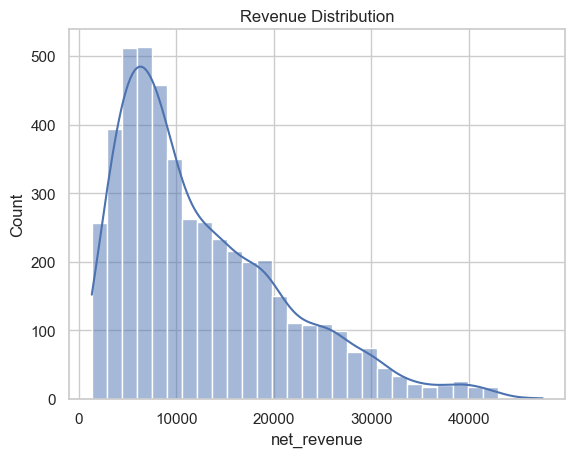

In [56]:
logging.info("Univariate Analysis - Revenue")

sns.histplot(orders["net_revenue"], bins=30, kde=True)
plt.title("Revenue Distribution")
plt.show()

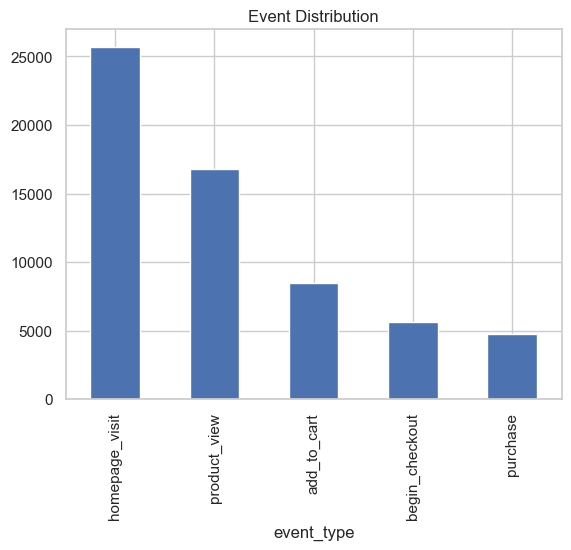

In [57]:
logging.info("Event distribution analysis")

events["event_type"].value_counts().plot(kind="bar")
plt.title("Event Distribution")
plt.show()

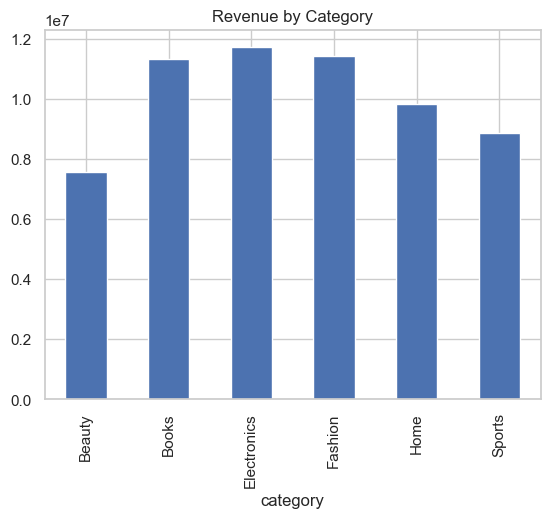

In [58]:
logging.info("Bivariate analysis: category vs revenue")

merged = orders.merge(products, on="product_id")

category_sales = merged.groupby("category")["net_revenue"].sum()

category_sales.plot(kind="bar")
plt.title("Revenue by Category")
plt.show()

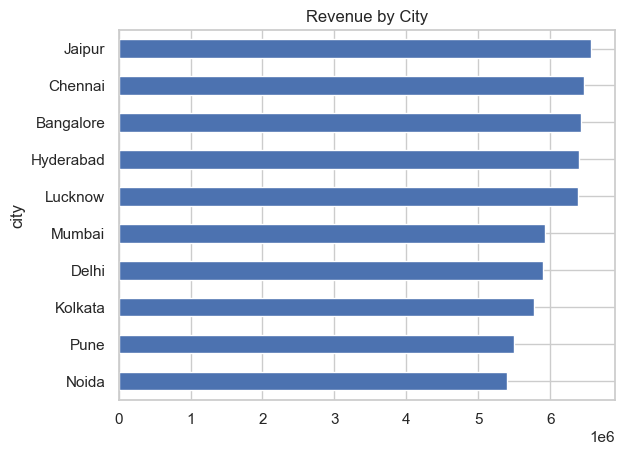

In [59]:
logging.info("City revenue analysis")

merged_users = orders.merge(users, on="user_id")

city_sales = merged_users.groupby("city")["net_revenue"].sum()

city_sales.sort_values().plot(kind="barh")
plt.title("Revenue by City")
plt.show()

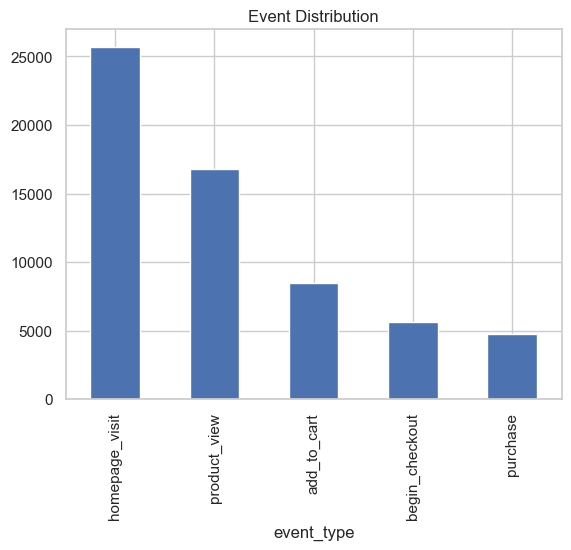

In [60]:
logging.info("Event distribution analysis")

events["event_type"].value_counts().plot(kind="bar")
plt.title("Event Distribution")
plt.show()

In [61]:
logging.info("Funnel analysis started")

funnel = events["event_type"].value_counts()

print(funnel)

event_type
homepage_visit    25683
product_view      16805
add_to_cart        8503
begin_checkout     5619
purchase           4778
Name: count, dtype: int64


In [62]:
conversion = funnel / funnel["homepage_visit"] * 100

print(conversion)

event_type
homepage_visit    100.000000
product_view       65.432387
add_to_cart        33.107503
begin_checkout     21.878285
purchase           18.603746
Name: count, dtype: float64


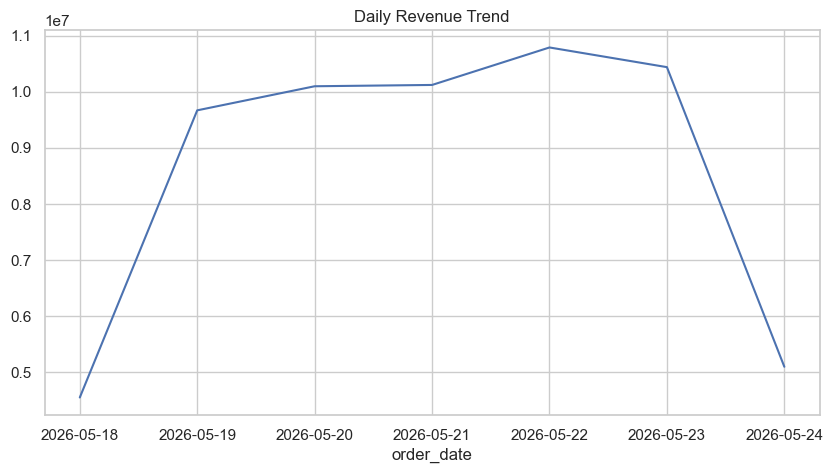

In [63]:
logging.info("Time series analysis")

orders["order_date"] = pd.to_datetime(orders["order_date"])

daily_sales = orders.groupby(
    orders["order_date"].dt.date
)["net_revenue"].sum()

daily_sales.plot(figsize=(10,5))
plt.title("Daily Revenue Trend")
plt.show()

In [64]:
logging.info("Cohort analysis")

cohort_df = orders.merge(users, on="user_id")

cohort_df["order_date"] = pd.to_datetime(cohort_df["order_date"])
cohort_df["sign_up_date"] = pd.to_datetime(cohort_df["sign_up_date"])

cohort_df["cohort_month"] = cohort_df["sign_up_date"].dt.to_period("M")
cohort_df["order_month"] = cohort_df["order_date"].dt.to_period("M")

cohort_table = cohort_df.groupby(
    ["cohort_month", "order_month"]
)["user_id"].nunique().unstack()

print(cohort_table)

order_month   2026-05
cohort_month         
2024-05            23
2024-06           108
2024-07           128
2024-08           119
2024-09           135
2024-10           127
2024-11           124
2024-12           123
2025-01           127
2025-02           102
2025-03           140
2025-04           100
2025-05           134
2025-06           136
2025-07           134
2025-08           114
2025-09           120
2025-10           143
2025-11           136
2025-12           108
2026-01           127
2026-02           100
2026-03           131
2026-04           124
2026-05            95


In [65]:
logging.info("Outlier detection started")

Q1 = orders["net_revenue"].quantile(0.25)
Q3 = orders["net_revenue"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = orders[
    (orders["net_revenue"] < lower) |
    (orders["net_revenue"] > upper)
]

logging.info(f"Outliers detected: {len(outliers)}")

print("Outliers:", len(outliers))

Outliers: 101


In [66]:
logging.info("Generating business insights")

print("\nTOTAL REVENUE:", orders["net_revenue"].sum())

print("TOP CATEGORY:",
      merged.groupby("category")["net_revenue"].sum().idxmax())

print("TOP CITY:",
      merged_users.groupby("city")["net_revenue"].sum().idxmax())

print("TOTAL ORDERS:", len(orders))


TOTAL REVENUE: 60734726.370000005
TOP CATEGORY: Electronics
TOP CITY: Jaipur
TOTAL ORDERS: 4778


In [67]:
logging.info("EDA Pipeline Completed Successfully")
logging.info(f"Batch processed: {metadata['batch_id']}")